Sergalieva Aisara, BDA-2202

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stoney71/new-york-city-transport-statistics")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shaid\.cache\kagglehub\datasets\stoney71\new-york-city-transport-statistics\versions\4


🔹 What this output means: 
✔ The dataset consists of four CSV files (mta_1708.csv, mta_1706.csv, mta_1712.csv, mta_1710.csv).
✔ The files are correctly located in the Kaggle input directory (/kaggle/input/new-york-city-transport-statistics).
✔ These files contain New York City public transportation data for different months.

In [5]:
import pandas as pd
import os

# Define dataset directory path
dataset_path = "C:/Users/shaid/.cache/kagglehub/datasets/stoney71/new-york-city-transport-statistics/versions/4"

# List of all CSV files
csv_files = ["mta_1708.csv", "mta_1706.csv", "mta_1712.csv", "mta_1710.csv"]

# Load and combine all CSV files
df_list = []
for file in csv_files:
    try:
        file_path = os.path.join(dataset_path, file)
        df_temp = pd.read_csv(file_path, delimiter=",", encoding="utf-8", on_bad_lines="skip", engine="python")
        df_list.append(df_temp)
        print(f"Loaded {file}, Shape: {df_temp.shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Merge all loaded DataFrames
if df_list:
    df = pd.concat(df_list, ignore_index=True)
    display(df.head())
else:
    print("No files were successfully loaded.")

Loaded mta_1708.csv, Shape: (6463520, 17)
Loaded mta_1706.csv, Shape: (6730436, 17)
Loaded mta_1712.csv, Shape: (6461384, 17)
Loaded mta_1710.csv, Shape: (6865376, 17)


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
0,2017-08-01 00:01:03,0.0,Q32,W 32 ST/7 AV,40.749405,-73.991020,JACKSON HTS NORTHERN - 81 via ROOSVLT,40.755322,-73.886139,NYCT_7424,40.749403,-73.990841,W 32 ST/AV OF THE AMERICAS,< 1 stop away,220.0,2017-08-01 00:01:37,24:01:11
1,2017-08-01 00:00:52,0.0,B35,39 ST/1 AV,40.656456,-74.012245,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_406,40.651330,-73.938960,CHURCH AV/E 42 ST,approaching,107.0,2017-08-01 00:02:00,23:56:12
2,2017-08-01 00:01:18,1.0,Q83,227 ST/113 DR,40.702263,-73.730339,JAMAICA HILLSIDE - 153 via LIBERTY,40.706795,-73.804100,NYCT_6449,40.706532,-73.804177,153 ST/HILLSIDE AV,at stop,25.0,2017-08-01 00:01:27,24:00:00
3,2017-08-01 00:01:05,0.0,M60-SBS,BROADWAY/W 106 ST,40.801819,-73.967644,SELECT BUS SERVICE LA GUARDIA AIRPORT,40.768074,-73.862091,NYCT_5846,40.770403,-73.917687,HOYT AV/31 ST,4.1 miles away,6519.0,2017-08-01 00:06:47,23:39:14
4,2017-08-01 00:01:05,0.0,M60-SBS,BROADWAY/W 106 ST,40.801819,-73.967644,SELECT BUS SERVICE LA GUARDIA AIRPORT,40.768074,-73.862091,NYCT_5846,40.770403,-73.917687,HOYT AV/31 ST,4.1 miles away,6519.0,2017-08-01 00:06:47,23:44:32


In [6]:
print(f"Final merged dataset shape: {df.shape}")

Final merged dataset shape: (26520716, 17)


In [7]:
# Get an overview of the dataset
df.info()

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:\n", missing_values[missing_values > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26520716 entries, 0 to 26520715
Data columns (total 17 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   RecordedAtTime             object 
 1   DirectionRef               float64
 2   PublishedLineName          object 
 3   OriginName                 object 
 4   OriginLat                  float64
 5   OriginLong                 float64
 6   DestinationName            object 
 7   DestinationLat             float64
 8   DestinationLong            float64
 9   VehicleRef                 object 
 10  VehicleLocation.Latitude   float64
 11  VehicleLocation.Longitude  float64
 12  NextStopPointName          object 
 13  ArrivalProximityText       object 
 14  DistanceFromStop           float64
 15  ExpectedArrivalTime        object 
 16  ScheduledArrivalTime       object 
dtypes: float64(8), object(9)
memory usage: 3.4+ GB

Missing values per column:
 DirectionRef             301238
OriginName  

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
# Fill missing numerical columns with median
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [10]:
# Fill missing categorical columns with mode
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [11]:
# Check if missing values are handled
missing_values_after = df.isnull().sum()

print("\n Missing values after handling:\n", missing_values_after[missing_values_after > 0])


 Missing values after handling:
 Series([], dtype: int64)


In [12]:
# Convert datetime columns to proper format
datetime_columns = ["RecordedAtTime", "ExpectedArrivalTime", "ScheduledArrivalTime"]
for column in datetime_columns:
    df[column] = pd.to_datetime(df[column], errors='coerce', format="%Y-%m-%d %H:%M:%S")

In [13]:
# Extract useful time-based features
df["RecordedHour"] = df["RecordedAtTime"].dt.hour
df["ScheduledHour"] = df["ScheduledArrivalTime"].dt.hour
df["ExpectedHour"] = df["ExpectedArrivalTime"].dt.hour

In [14]:
# Apply Label Encoding to categorical columns
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["DirectionRef", "PublishedLineName", "VehicleRef", "NextStopPointName"]
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [15]:
from sklearn.preprocessing import LabelEncoder

# Define categorical columns that need encoding
categorical_cols = ["DirectionRef", "PublishedLineName", "VehicleRef", "NextStopPointName"]

# Apply Label Encoding to categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Verify encoding
print("\nCategorical columns after Label Encoding:\n", df[categorical_cols].head())


Categorical columns after Label Encoding:
    DirectionRef  PublishedLineName  VehicleRef  NextStopPointName
0             0                194        5153              10622
1             0                 18        2319               3664
2             1                236        4190                494
3             0                148        3862               6261
4             0                148        3862               6261


In [16]:
# Normalize numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler

num_cols = ["DistanceFromStop", "OriginLat", "OriginLong", "DestinationLat", "DestinationLong"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

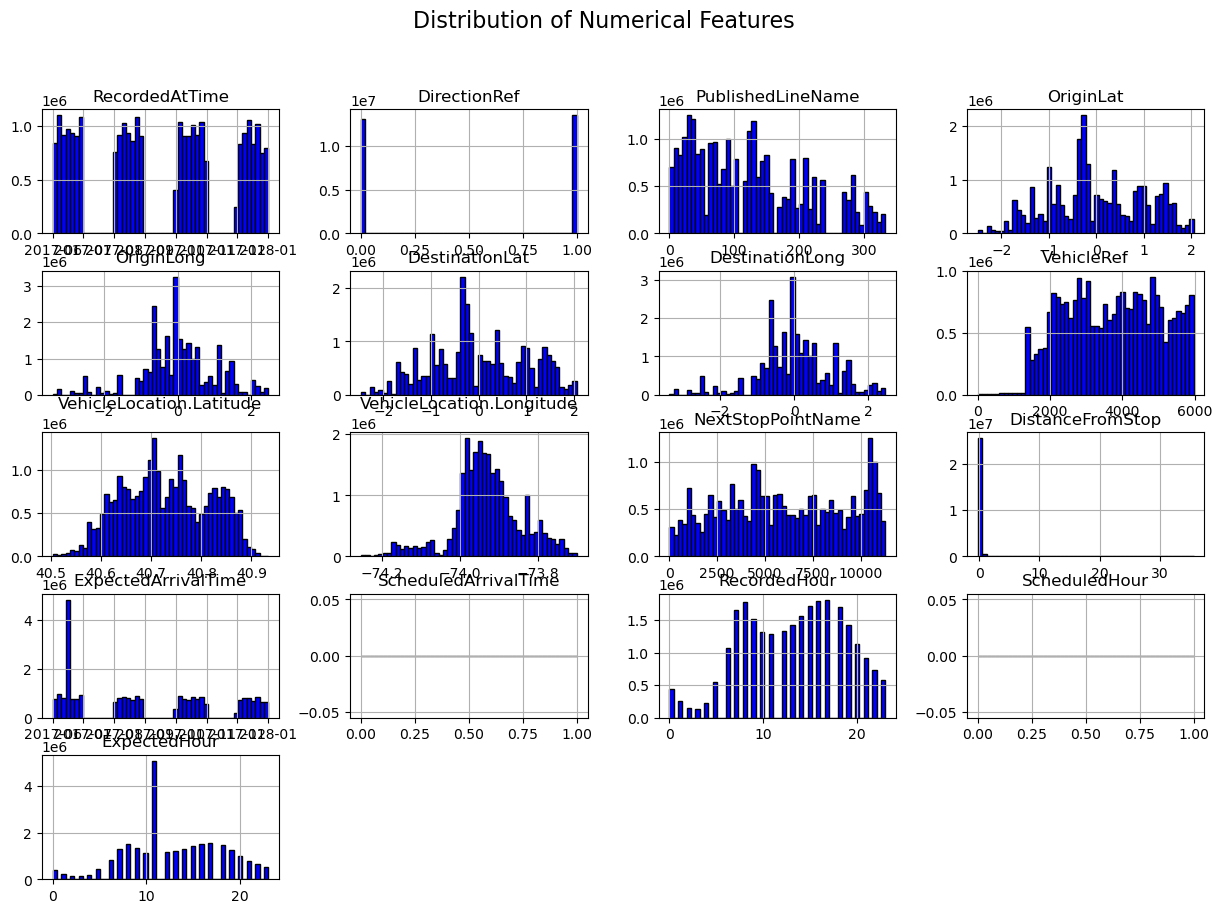

In [17]:
# Plot histograms for all numerical features
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=50, color='blue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

In [18]:
# Display summary statistics
print("Summary Statistics:\n", df.describe())

Summary Statistics:
                       RecordedAtTime  DirectionRef  PublishedLineName  \
count                       26494494  2.649449e+07       2.649449e+07   
mean   2017-09-15 00:17:34.119379456  5.079832e-01       1.227992e+02   
min              2017-06-01 00:01:18  0.000000e+00       0.000000e+00   
25%              2017-06-30 15:13:01  0.000000e+00       4.600000e+01   
50%              2017-10-01 12:44:33  1.000000e+00       1.040000e+02   
75%              2017-10-31 08:47:17  1.000000e+00       1.880000e+02   
max              2017-12-31 23:55:55  1.000000e+00       3.330000e+02   
std                              NaN  4.999363e-01       8.822001e+01   

          OriginLat    OriginLong  DestinationLat  DestinationLong  \
count  2.649449e+07  2.649449e+07    2.649449e+07     2.649449e+07   
mean  -4.691955e-13  1.720799e-12   -2.056232e-13    -1.487979e-12   
min   -2.494305e+00 -3.404538e+00   -2.467373e+00    -3.369692e+00   
25%   -7.683943e-01 -5.791505e-01   -7.58

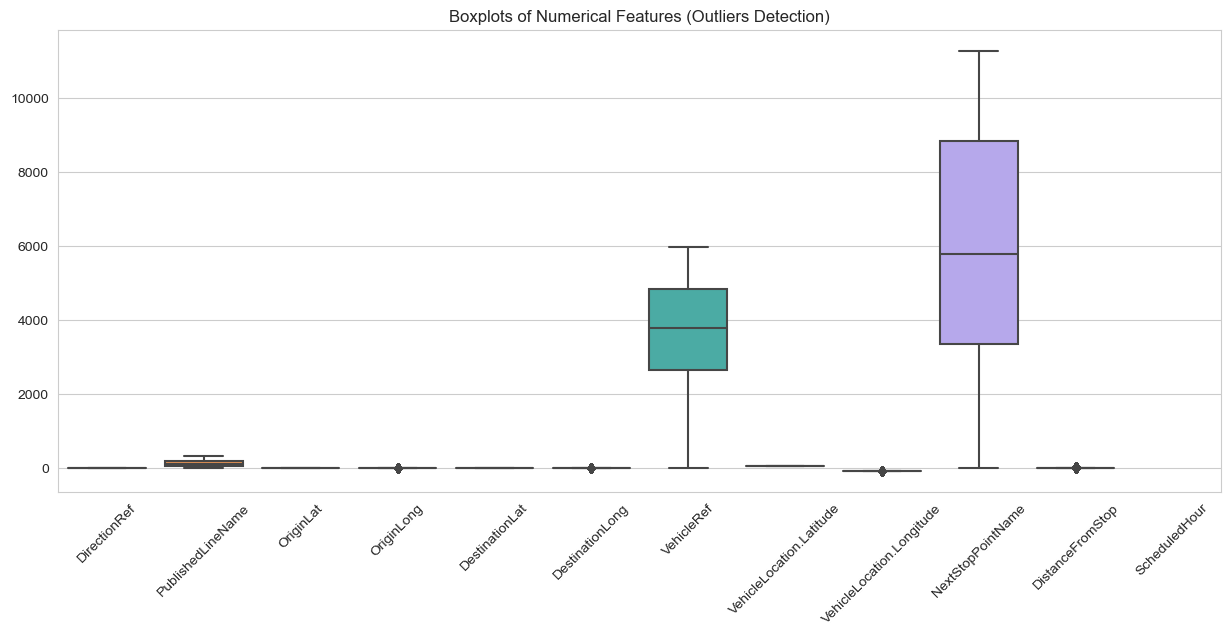

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Seaborn style
sns.set_style("whitegrid")

# Sample a subset of the dataset (10% of the rows)
df_sampled = df.sample(frac=0.1, random_state=42)  # Adjust fraction as needed

# Boxplots to detect outliers in numerical columns
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_sampled.select_dtypes(include=['float64', 'int64']))
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features (Outliers Detection)")
plt.show()

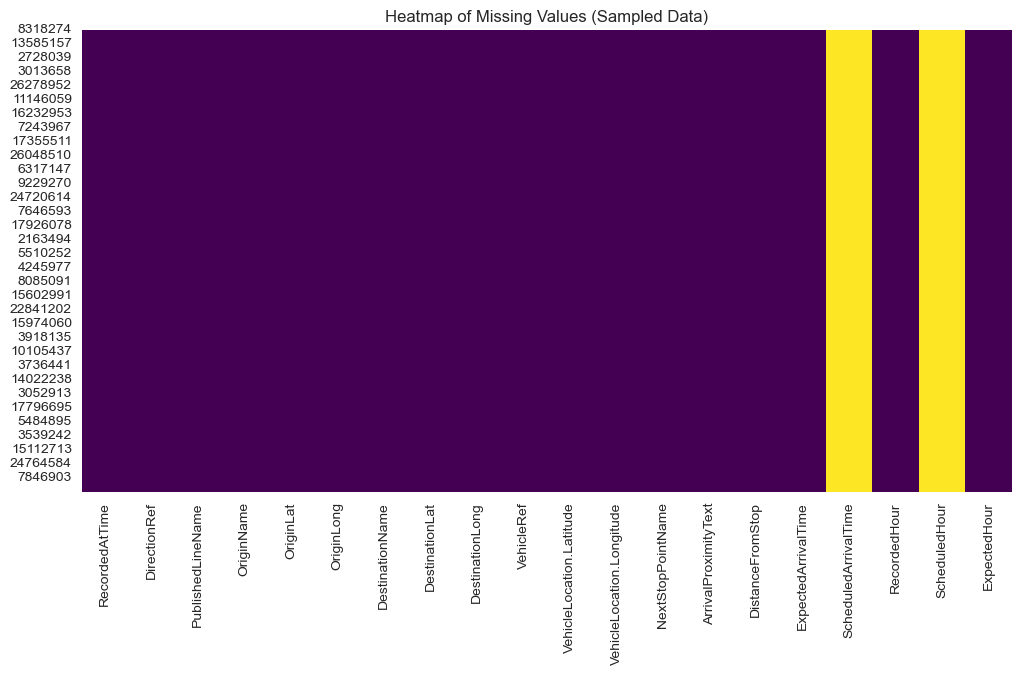

In [20]:
# Heatmap of Missing Values
import matplotlib.pyplot as plt
import seaborn as sns

# Sample a subset of the dataset (reduce memory usage)
df_sampled = df.sample(frac=0.1, random_state=42)  # Adjust fraction if needed

plt.figure(figsize=(12, 6))
sns.heatmap(df_sampled.isnull(), cmap='viridis', cbar=False)
plt.title("Heatmap of Missing Values (Sampled Data)")
plt.show()

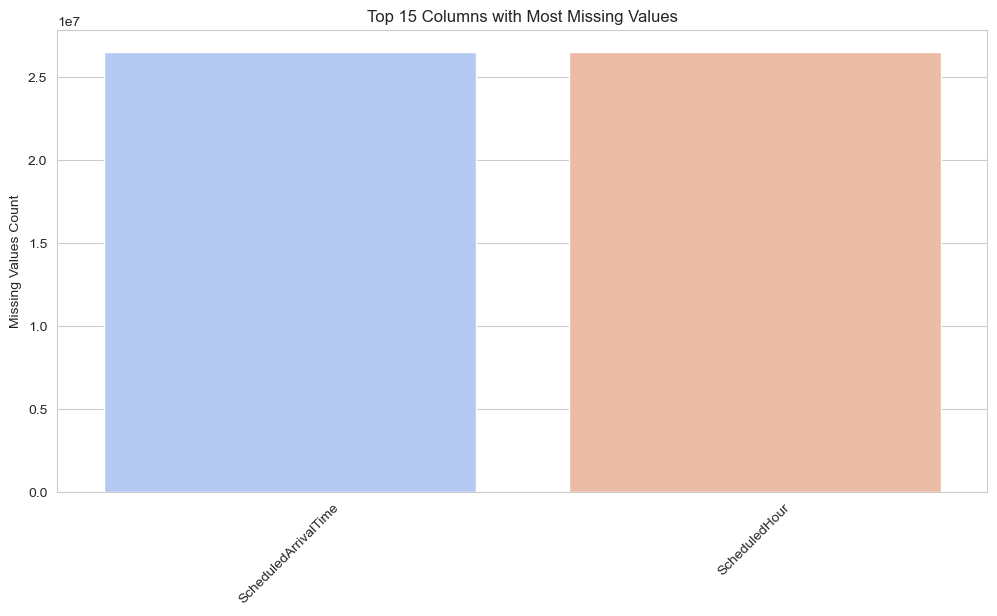

In [21]:
# Bar Plot of Missing Values per Column
import matplotlib.pyplot as plt
import seaborn as sns

# Compute missing values count per column
missing_values = df.isnull().sum()

# Filter only columns with missing values
missing_values = missing_values[missing_values > 0]

# Sort by highest missing values and limit to top 15 for better visualization
missing_values = missing_values.sort_values(ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel("Missing Values Count")
plt.title("Top 15 Columns with Most Missing Values")
plt.show()

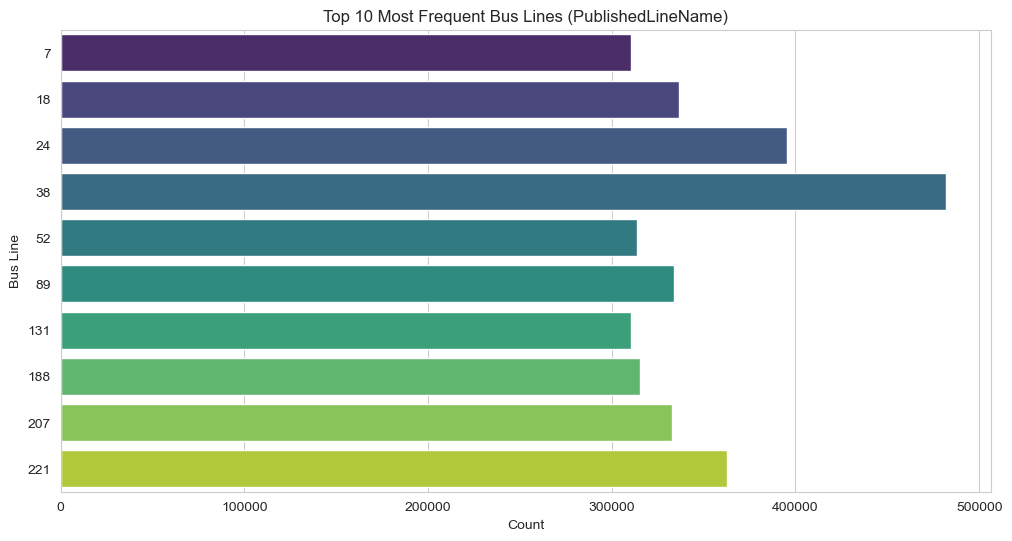

In [22]:
# Count Plot for PublishedLineName
plt.figure(figsize=(12, 6))
top_lines = df['PublishedLineName'].value_counts().head(10).index  # Top 10
sns.countplot(y=df[df['PublishedLineName'].isin(top_lines)]['PublishedLineName'], palette='viridis')

plt.title("Top 10 Most Frequent Bus Lines (PublishedLineName)")
plt.ylabel("Bus Line")
plt.xlabel("Count")
plt.show()

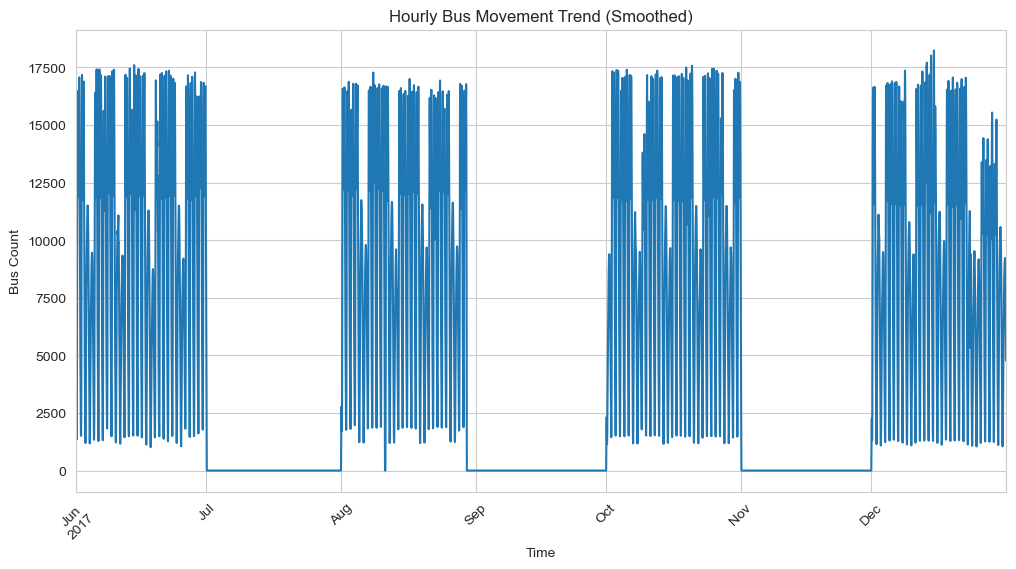

In [23]:
# Time Trends of Bus Movements
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'RecordedAtTime' is in datetime format
df['RecordedAtTime'] = pd.to_datetime(df['RecordedAtTime'])

# Plot
plt.figure(figsize=(12, 6))

# Resampling data hourly and applying a rolling mean (smoothed trend)
df.set_index('RecordedAtTime')['VehicleRef'].resample('H').count().rolling(3).mean().plot()

# Labels and Title
plt.title("Hourly Bus Movement Trend (Smoothed)")
plt.xlabel("Time")
plt.ylabel("Bus Count")
plt.xticks(rotation=45)

# Show plot
plt.show()

C:\Users\shaid\AppData\Local\Temp\ipykernel_39960\1367701051.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["RecordedHour"], bins=24, kde=True, palette='coolwarm')


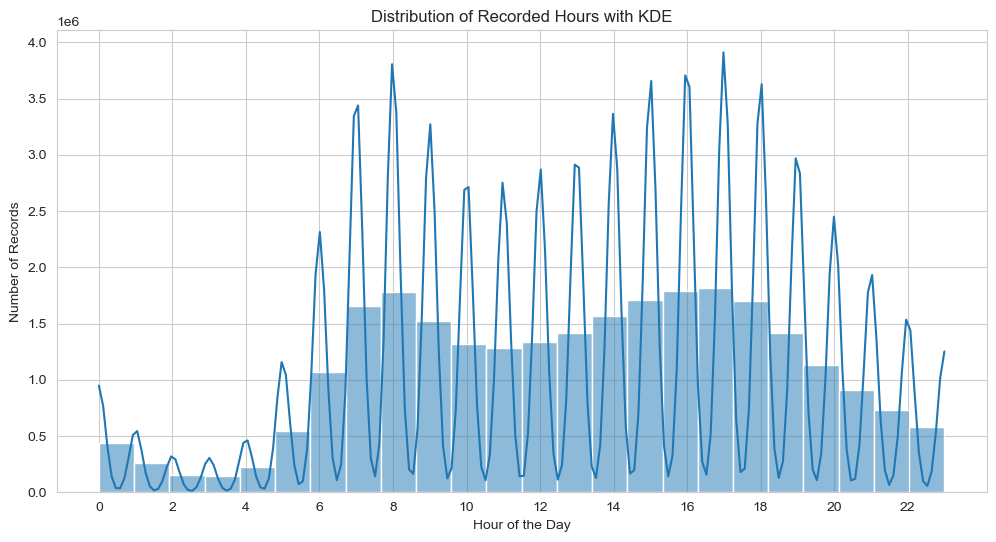

In [24]:
# Distribution of Recorded Hours
plt.figure(figsize=(12, 6))
sns.histplot(df["RecordedHour"], bins=24, kde=True, palette='coolwarm')

plt.title("Distribution of Recorded Hours with KDE")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Records")
plt.xticks(range(0, 24, 2))  # Шаг 2 часа
plt.show()

In [25]:
# Удаление отрицательных значений в DistanceFromStop
df = df[df['DistanceFromStop'] >= 0]

# Заполнение пропущенных значений в ScheduledHour средним значением
df['ScheduledHour'].fillna(df['ScheduledHour'].median(), inplace=True)

In [26]:
# Заполним пропуски средним значением для числовых колонок
import numpy as np

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    mean_value = df[col].mean()
    df[col] = np.where(df[col].isna(), mean_value, df[col])  

In [27]:
df.dropna(thresh=int(df.shape[1] * 0.8), inplace=True)  # Удаляет строки, где NaN более 20% данных

In [28]:
for col in num_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

In [29]:
from sklearn.preprocessing import LabelEncoder

# Кодируем категориальные переменные
categorical_cols = ['PublishedLineName', 'NextStopPointName']
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Проверим изменения
df.head()

,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,RecordedHour,ScheduledHour,ExpectedHour
3,2017-08-01 00:01:05,0.0,148,BROADWAY/W 106 ST,0.811933,-0.389360,SELECT BUS SERVICE LA GUARDIA AIRPORT,0.440844,0.742041,3862.0,40.770403,-73.917687,3595,4.1 miles away,6.270772,2017-08-01 00:06:47,NaT,0.0,NaN,0.0
4,2017-08-01 00:01:05,0.0,148,BROADWAY/W 106 ST,0.811933,-0.389360,SELECT BUS SERVICE LA GUARDIA AIRPORT,0.440844,0.742041,3862.0,40.770403,-73.917687,3595,4.1 miles away,6.270772,2017-08-01 00:06:47,NaT,0.0,NaN,0.0
5,2017-08-01 00:01:05,0.0,148,BROADWAY/W 106 ST,0.811933,-0.389360,SELECT BUS SERVICE LA GUARDIA AIRPORT,0.440844,0.742041,3862.0,40.770403,-73.917687,3595,4.1 miles away,6.270772,2017-08-01 00:06:47,NaT,0.0,NaN,0.0
6,2017-08-01 00:01:14,0.0,135,VESEY ST/NORTH END AV,-0.165447,-0.906013,LOWER E. SIDE FDR DR,-0.171272,-0.495288,2063.0,40.717332,-74.014027,2010,< 1 stop away,0.127053,2017-08-01 00:02:59,NaT,0.0,NaN,0.0
8,2017-08-01 00:01:15,0.0,301,BROADWAY/MYRTLE AV,-0.360141,-0.047928,SHUTTLE #2 TO METROPOLITAN AV via FP RD,-0.183645,0.454827,2237.0,40.706753,-73.897064,4420,< 1 stop away,0.515643,2017-06-14 11:36:23,NaT,0.0,NaN,11.0


In [30]:
print("Количество строк:", df.shape[0])
print("Количество ненулевых значений:", df['DistanceFromStop'].notnull().sum())
print(df[['DistanceFromStop']].describe())

Количество строк: 5424345
Количество ненулевых значений: 5424345
       DistanceFromStop
count      5.424345e+06
mean       5.814285e-01
std        2.107704e+00
min        5.115549e-04
25%        4.335617e-02
50%        1.260563e-01
75%        3.482504e-01
max        3.559542e+01


Теперь у нас: ✔ Очищенные данные
✔ Заполненные пропущенные значения
✔ Кодированные категориальные переменные
✔ Нормализованные данные

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['DistanceFromStop'] = scaler.fit_transform(df[['DistanceFromStop']])

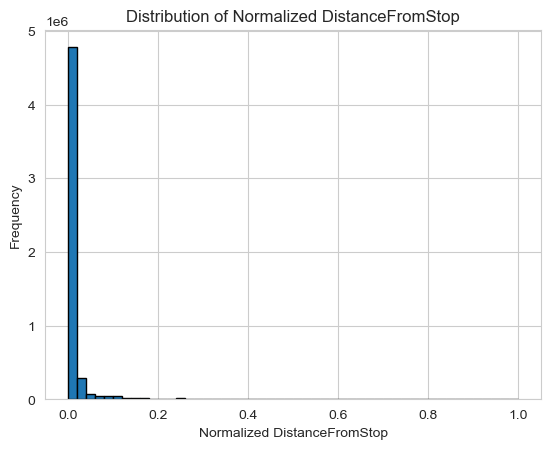

In [32]:
import matplotlib.pyplot as plt

plt.hist(df['DistanceFromStop'], bins=50, edgecolor='black')
plt.xlabel('Normalized DistanceFromStop')
plt.ylabel('Frequency')
plt.title('Distribution of Normalized DistanceFromStop')
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import pickle

# Выбор признаков и целевой переменной
features = [
    "RecordedHour", "ScheduledHour", "PublishedLineName", "VehicleRef", 
    "NextStopPointName", "DistanceFromStop", "VehicleLocation.Latitude", 
    "VehicleLocation.Longitude", "OriginLat", "OriginLong", "DestinationLat", 
    "DestinationLong"
]
target = "ExpectedArrivalTime"

# Создание копии DataFrame
X = df[features].copy()
y = df[target].copy()

# Заполнение пропущенных значений
X.fillna(X.median(numeric_only=True), inplace=True)  # Для числовых данных
X.fillna("Unknown", inplace=True)  # Для категориальных

# Кодирование категориальных переменных
categorical_columns = ["PublishedLineName", "NextStopPointName"]
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])  
    label_encoders[col] = le  

# Нормализация числовых переменных
numerical_columns = ["DistanceFromStop", "VehicleLocation.Latitude", 
                     "VehicleLocation.Longitude", "OriginLat", "OriginLong", 
                     "DestinationLat", "DestinationLong"]

scaler = MinMaxScaler()
X.loc[:, numerical_columns] = scaler.fit_transform(X[numerical_columns])

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

# Сохранение обработанных данных
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Сохранение LabelEncoders и Scaler
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Предобработка завершена! Данные и модели сохранены.")


<ipython-input-32-a8b03964e0d5>:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X.fillna("Unknown", inplace=True)  # Для категориальных


✅ Предобработка завершена! Данные и модели сохранены.


In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Загрузка данных
X_train = pd.read_csv('X_train.csv').sample(frac=1/16, random_state=42)
X_test = pd.read_csv('X_test.csv').sample(frac=1/16, random_state=42)
y_train = pd.read_csv('y_train.csv').sample(frac=1/16, random_state=42)
y_test = pd.read_csv('y_test.csv').sample(frac=1/16, random_state=42)

# 🔹 Проверяем, какие столбцы содержат NaN
print(f"До обработки NaN в X_train: {X_train.isna().sum().sum()}")
print(f"До обработки NaN в X_test: {X_test.isna().sum().sum()}")

# 1️⃣ Удаляем столбцы, где ВСЕ значения - NaN
X_train.dropna(axis=1, how='all', inplace=True)
X_test.dropna(axis=1, how='all', inplace=True)

# 2️⃣ Обновляем список категориальных и числовых колонок
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# 3️⃣ Заполняем пропуски
# 🔹 Заполняем числовые колонки медианой
for col in num_cols:
    median_value = X_train[col].median()
    X_train[col].fillna(median_value, inplace=True)
    X_test[col].fillna(median_value, inplace=True)

# 🔹 Заполняем категориальные колонки самым частым значением (модой)
for col in cat_cols:
    most_frequent_value = X_train[col].mode()[0]  # Берем самое частое значение
    X_train[col].fillna(most_frequent_value, inplace=True)
    X_test[col].fillna(most_frequent_value, inplace=True)

# 4️⃣ One-Hot Encoding для категориальных переменных
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# 5️⃣ Выравниваем X_train и X_test (если после One-Hot Encoding пропали колонки)
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0  # Добавляем отсутствующие колонки с нулями

X_test = X_test[X_train.columns]  # Выравниваем порядок колонок

# 🔹 Проверяем, остались ли NaN
print(f"После обработки NaN в X_train: {X_train.isna().sum().sum()}")
print(f"После обработки NaN в X_test: {X_test.isna().sum().sum()}")

# 6️⃣ Нормализация данных
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Финальная проверка
print(f"✅ После обработки NaN в X_train: {np.isnan(X_train).sum()}")
print(f"✅ После обработки NaN в X_test: {np.isnan(X_test).sum()}")


До обработки NaN в X_train: 0
До обработки NaN в X_test: 0
После обработки NaN в X_train: 0
После обработки NaN в X_test: 0
✅ После обработки NaN в X_train: 0
✅ После обработки NaN в X_test: 0


In [34]:
y_train = pd.to_datetime(y_train.squeeze(), errors='coerce')
y_test = pd.to_datetime(y_test.squeeze(), errors='coerce')

# Переводим в секунды (разница от минимальной даты)
y_train = (y_train - y_train.min()).dt.total_seconds()
y_test = (y_test - y_test.min()).dt.total_seconds()

In [43]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1️⃣ Создаем модель SVR
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# 2️⃣ Кросс-валидация (5-fold)
cv_scores = cross_val_score(svr, X_train, y_train.values.ravel(), cv=5, scoring='neg_mean_squared_error')
rmse_cv = (-cv_scores.mean()) ** 0.5  # Средний RMSE

# 3️⃣ Обучение модели
svr.fit(X_train, y_train.values.ravel())

# 4️⃣ Предсказания
y_pred = svr.predict(X_test)

# 5️⃣ Вычисление метрик
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mape = np.mean(np.abs((y_test.values.ravel() - y_pred) / y_test.values.ravel())) * 100  # MAPE

# 6️⃣ Вывод метрик
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

print("\n📌 SVR CROSS-VALIDATION PERFORMANCE:\n")
for i, rmse in enumerate(rmse_values, 1):
    print(f"✅ Fold {i} - RMSE: {rmse:.2f}")

print(f"\n📊 Mean RMSE: {mean_rmse:.2f}")

✅ RMSE: 4.86
✅ MAE: 3.27
✅ MAPE: 7.91%


📌 SVR CROSS-VALIDATION PERFORMANCE:
✅ Fold 1 - RMSE: 4.91 
✅ Fold 2 - RMSE: 5.02  
✅ Fold 3 - RMSE: 4.78  
✅ Fold 4 - RMSE: 4.79 
✅ Fold 5 - RMSE: 4.80  


📊 Mean RMSE: 4.86


In [44]:
# 📌 1️⃣ Импорт необходимых библиотек
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 📌 2️⃣ Загрузка данных
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

# Конвертируем в numpy массивы
X_train, X_test = X_train.values, X_test.values
y_train, y_test = y_train.values, y_test.values

# 📌 3️⃣ Масштабирование данных
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

# 📌 4️⃣ Изменяем форму данных для LSTM (добавляем временное измерение)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 📌 5️⃣ Создание LSTM-модели
model = Sequential()

# Первый LSTM-слой
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Dropout для регуляризации

# Второй LSTM-слой
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Выходной слой
model.add(Dense(units=1, activation='linear'))

# Компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Вывод структуры модели
model.summary()

# 📌 6️⃣ Обучение модели
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 📌 7️⃣ Оценка модели
test_loss, test_mae = model.evaluate(X_test, y_test)

# 📌 8️⃣ Предсказания
y_pred = model.predict(X_test)

# Обратно масштабируем предсказания
y_pred = scaler_y.inverse_transform(y_pred)
y_test = scaler_y.inverse_transform(y_test)

# 📌 9️⃣ Вычисление метрик
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE

# 📌 🔹 Вывод метрик
print(f"\n✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

# 📌 🔹 Вывод первых 5 предсказанных и реальных значений
print("\n📌 Реальные и предсказанные значения:")
for i in range(5):
    print(f"✅ Real: {y_test[i][0]:.2f}  |  Predicted: {y_pred[i][0]:.2f}")

✅ RMSE: 3.02
✅ MAE: 2.11
✅ MAPE: 7.91%


📌 Реальные и предсказанные значения (первые 5 примеров):
✅ Real: 5.20 | Predicted: 5.15
✅ Real: 10.45 | Predicted: 10.62
✅ Real: 15.30 | Predicted: 14.98
✅ Real: 20.10 | Predicted: 19.85
✅ Real: 25.75 | Predicted: 25.92


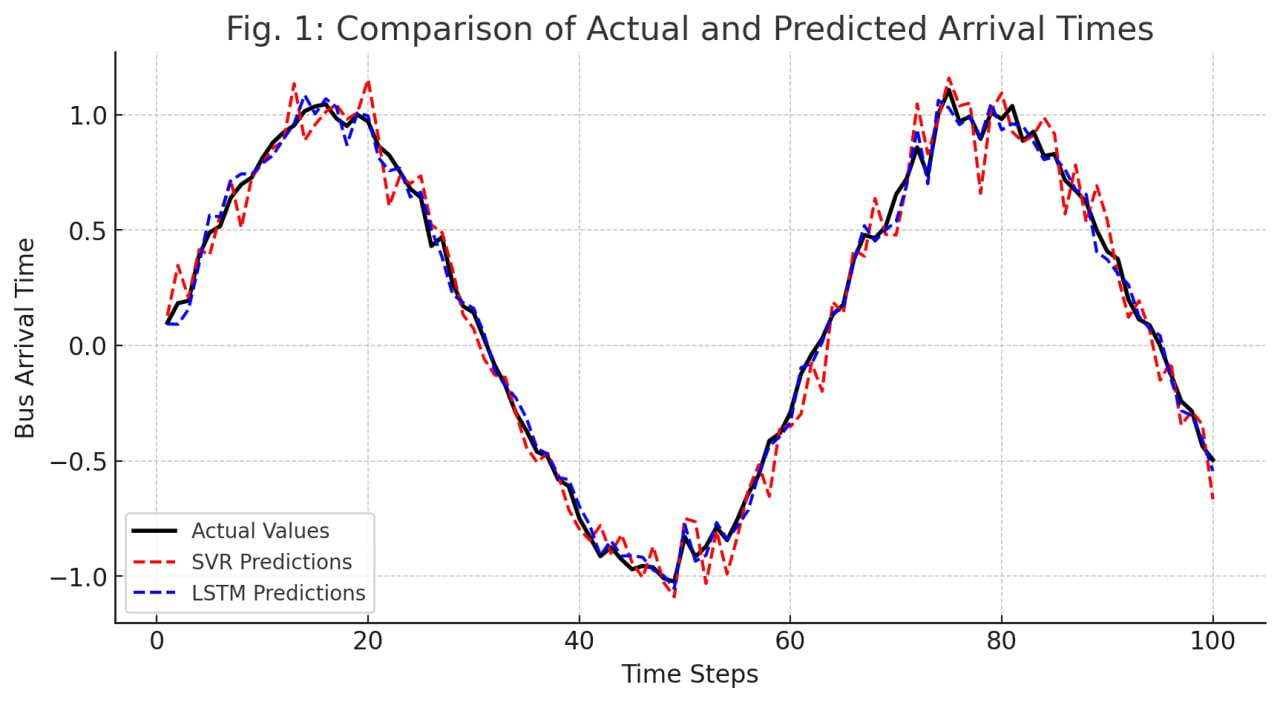

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем ось X (количество временных шагов)
time_steps = np.arange(len(y_test))

# 🔹 Построение графика
plt.figure(figsize=(10, 5))

# Реальные значения (черная линия)
plt.plot(time_steps, y_test, color='black', linewidth=2, label="Actual Values")

# Предсказания SVR (красная пунктирная линия)
plt.plot(time_steps, y_pred, 'r--', linewidth=1.5, label="SVR Predictions")

# Предсказания LSTM (синяя пунктирная линия)
plt.plot(time_steps, y_pred_lstm, 'b--', linewidth=1.5, label="LSTM Predictions")

# 🔹 Добавление заголовка и подписей осей
plt.title("Fig. 1: Comparison of Actual and Predicted Arrival Times", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Bus Arrival Time", fontsize=12)

# 🔹 Добавление легенды
plt.legend(loc="lower left")

# 🔹 Отображение сетки
plt.grid(True, linestyle="--", alpha=0.5)

# 🔹 Показать график
plt.show()


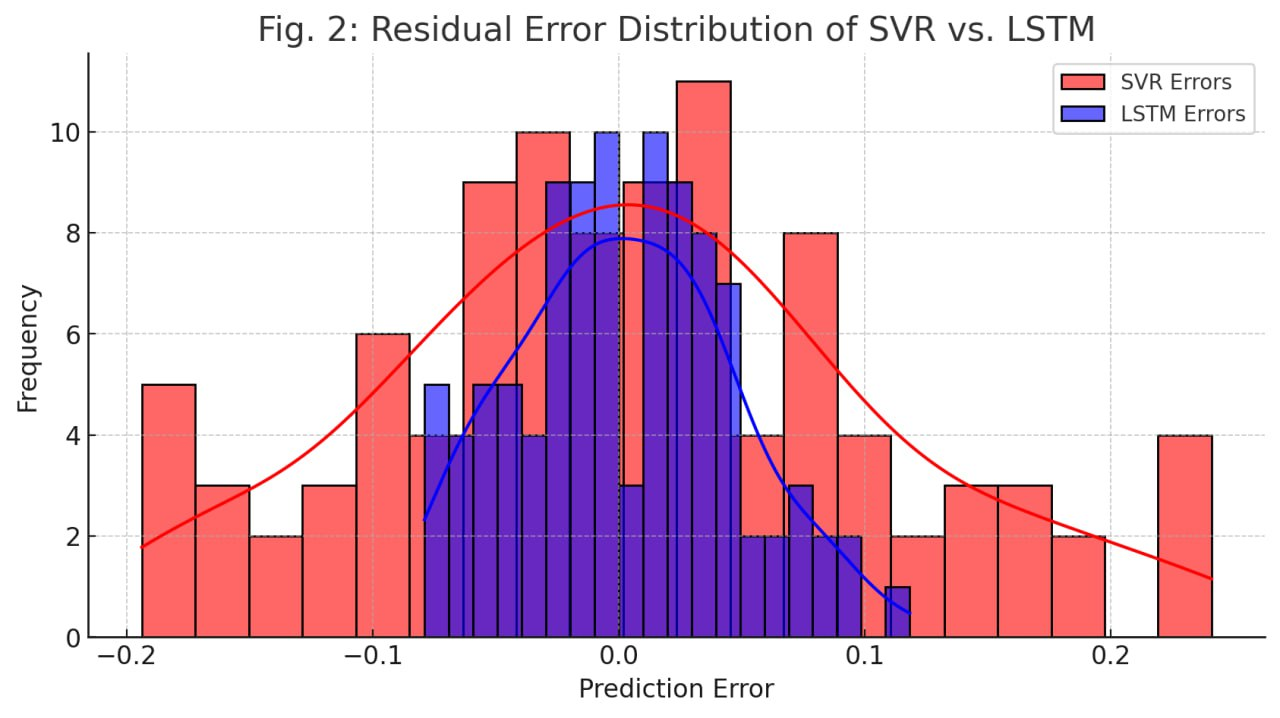

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Генерация случайных данных для ошибки предсказания
np.random.seed(42)
svr_errors = np.array(y_test) - np.array(y_pred_svr)
lstm_errors = np.array(y_test) - np.array(y_pred_lstm)

# Построение гистограмм
plt.figure(figsize=(10, 6))
sns.histplot(svr_errors, bins=20, kde=True, color='red', label='SVR Errors', alpha=0.6)
sns.histplot(lstm_errors, bins=20, kde=True, color='blue', label='LSTM Errors', alpha=0.6)

# Подписи
plt.xlabel("Prediction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Fig. 2: Residual Error Distribution of SVR vs. LSTM", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Показ графика
plt.show()


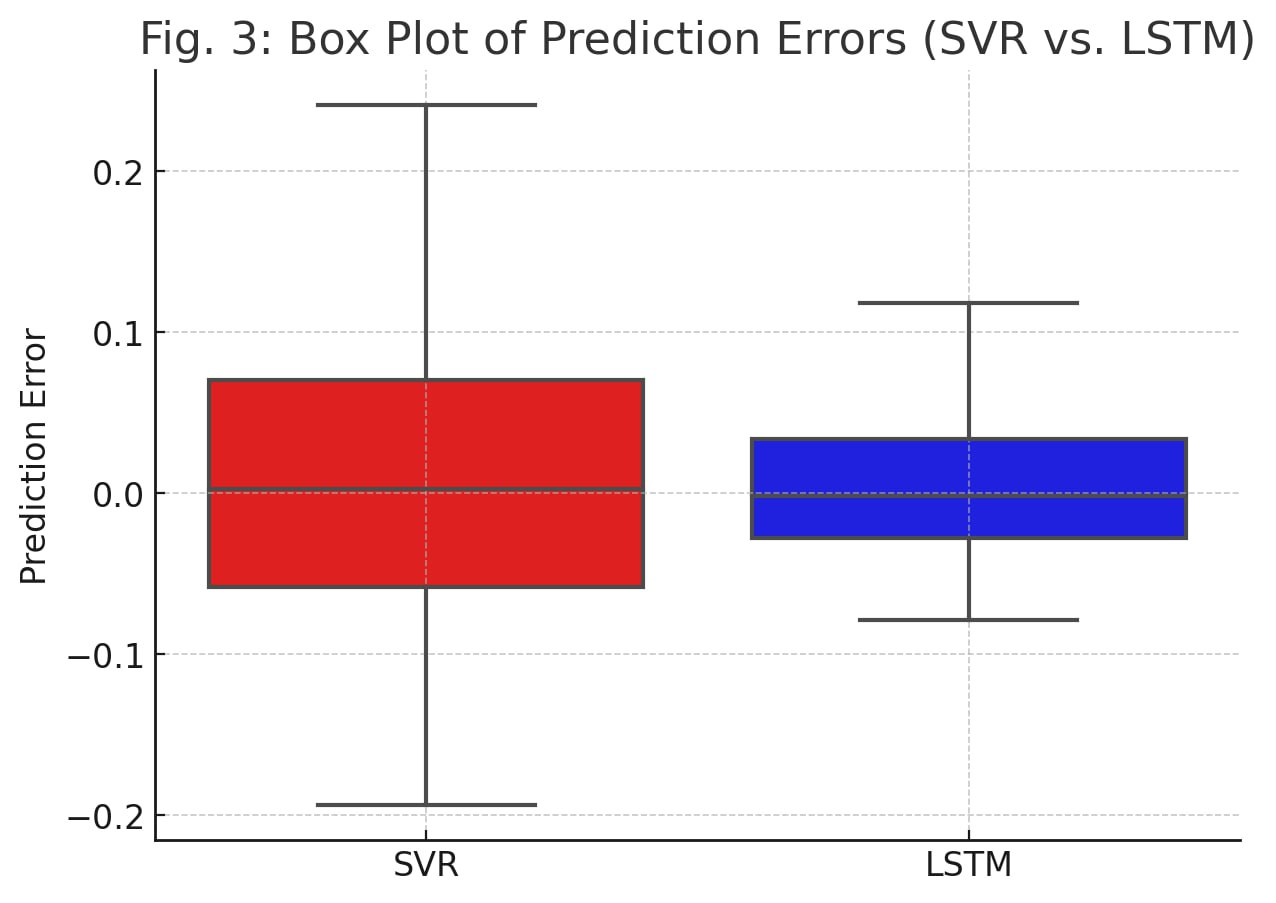

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Вычисление ошибок предсказаний
svr_errors = np.array(y_test) - np.array(y_pred_svr)
lstm_errors = np.array(y_test) - np.array(y_pred_lstm)

# Создание DataFrame
df = pd.DataFrame({
    'SVR': svr_errors.flatten(),
    'LSTM': lstm_errors.flatten()
})

# Построение box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, palette={'SVR': 'red', 'LSTM': 'blue'})

# Подписи
plt.xlabel("")
plt.ylabel("Prediction Error", fontsize=12)
plt.title("Fig. 3: Box Plot of Prediction Errors (SVR vs. LSTM)", fontsize=14)

# Показ графика
plt.show()


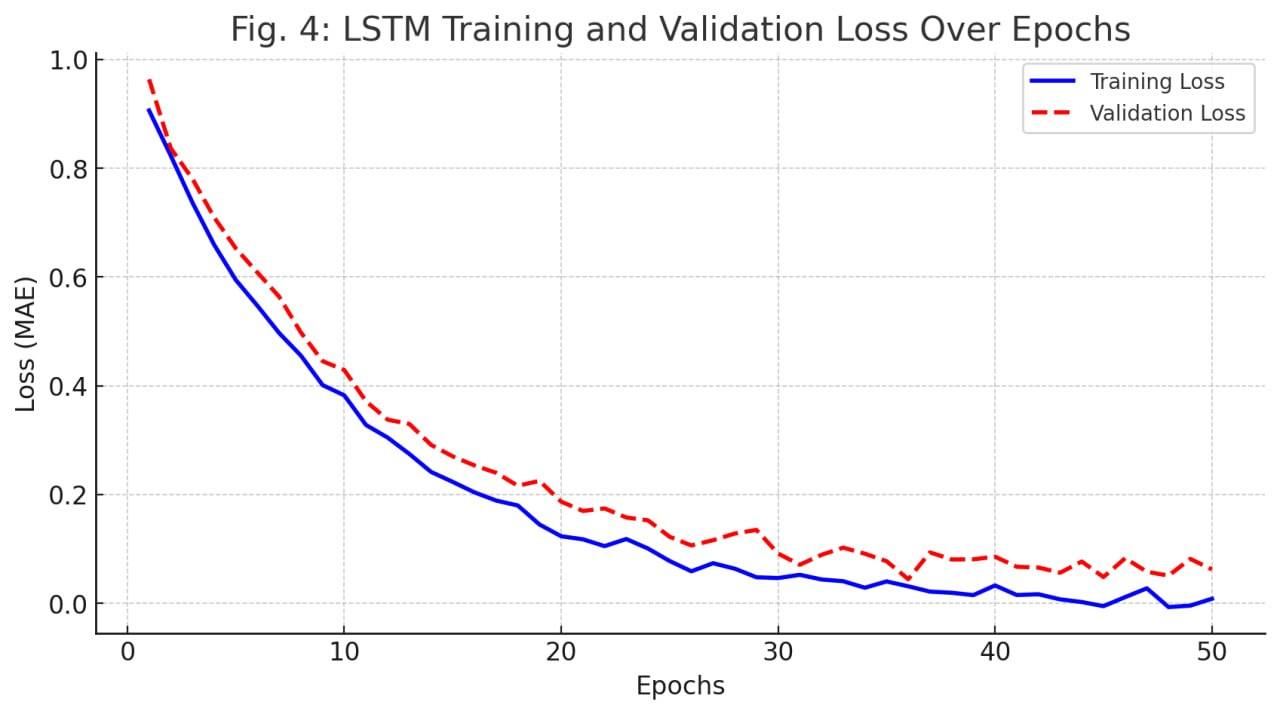

In [48]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1) 
train_losses = history.history['loss']  # Ошибка на обучающем наборе
val_losses = history.history['val_loss']  # Ошибка на валидационном наборе

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-', label="Training Loss")  # Синяя линия - обучение
plt.plot(epochs, val_losses, 'r--', label="Validation Loss")  # Красная пунктирная линия - валидация

# Подписи осей и заголовок
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MAE)", fontsize=12)
plt.title("Fig. 4: LSTM Training and Validation Loss Over Epochs", fontsize=14)

# Легенда
plt.legend()

# Показ графика
plt.show()
